# MARK 6580 - Customer Analytics
## Case Study 3 - Wahoo Fitness
### Mike Johnson

****

In [1]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load the survey data from the Excel file, using the 'Data' sheet
file_path = "Case Study 4 - Supplemental Segmentation.xlsx"
data = pd.read_excel(file_path, sheet_name='Data')

In [3]:
data.describe()

,Class?,QS2,QS3,AGE,hqAge,hqSportsParticipate_1,hqSportsParticipate_2,hqSportsParticipate_3,hqSportsParticipate_4,hqSportsParticipate_98,...,Q2_3,Q2_4,Q2_5,Q2_6,Q2_7,Q2_8,Q2_9,Q2_10,Q2_11,Q2_12
count,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000,959.0,1218.0,836.0,592.0,1290.0,...,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000,1313.000000
mean,1.828637,1.228484,79.617669,41.382331,5.932978,1.0,1.0,1.0,1.0,1.0,...,4.094440,3.708302,4.195735,3.658035,3.802742,3.818736,3.833968,3.773039,3.308454,3.781417
std,1.054333,0.420016,9.813430,9.813430,1.939265,0.0,0.0,0.0,0.0,0.0,...,0.993228,1.195545,0.981807,1.165909,1.124122,1.085119,1.271703,1.261038,1.329220,1.137722
min,0.000000,1.000000,56.000000,18.000000,1.000000,1.0,1.0,1.0,1.0,1.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,74.000000,35.000000,5.000000,1.0,1.0,1.0,1.0,1.0,...,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000
50%,2.000000,1.000000,81.000000,40.000000,6.000000,1.0,1.0,1.0,1.0,1.0,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000
75%,3.000000,1.000000,86.000000,47.000000,7.000000,1.0,1.0,1.0,1.0,1.0,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000
max,3.000000,2.000000,103.000000,65.000000,10.000000,1.0,1.0,1.0,1.0,1.0,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


****

#### Step 1: Select relevant columns for psychographic and profile data

In [4]:
# Identify columns for Q1, Q2, QS6, QS7, and sports activities
psychographic_columns = ['Q1_1', 'Q1_2', 'Q2_1', 'Q2_2', 'hqRun', 'hqCycle', 'hqTri']
qs6_columns = [col for col in data.columns if col.startswith('QS6')]
qs7_columns = [col for col in data.columns if col.startswith('QS7')]
all_psychographic_columns = psychographic_columns + qs6_columns + qs7_columns

****

#### Step 2: Data Preprocessing (Impute missing values and standardize the data)

In [5]:
# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[all_psychographic_columns])

In [6]:
# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

****

#### Step 3: Determine the optimal number of clusters using the Elbow Method

In [7]:
sse = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    sse.append(kmeans.inertia_)

c:\Users\Mike\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Mike\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Mike\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\Mike\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

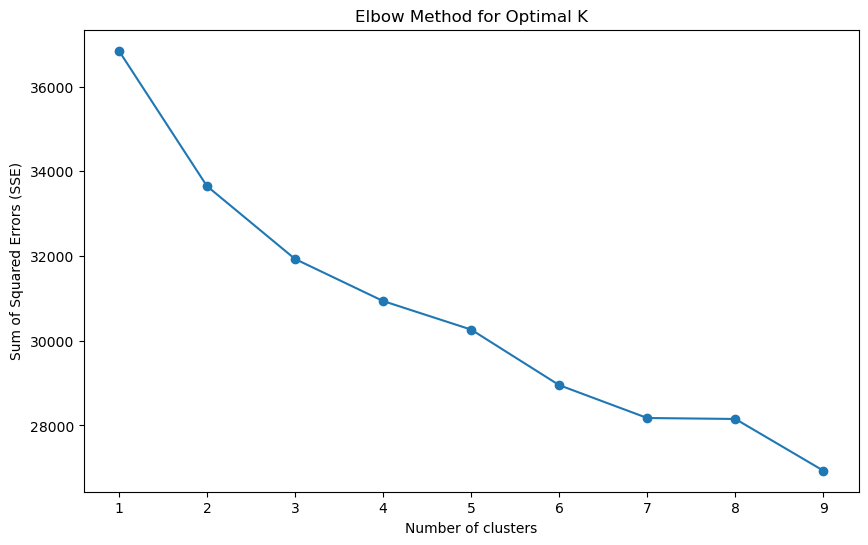

In [8]:
# Plot the elbow method graph to identify the optimal number of clusters
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.show()


****

#### Step 4: Fit K-means with the optimal number of clusters (based on elbow plot)

In [9]:
optimal_k = 3  # Adjust this number based on the elbow plot result
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['cluster'] = kmeans.fit_predict(data_scaled)


c:\Users\Mike\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


****

#### Step 5: Analyze the characteristics of the clusters (Fixed code for numeric columns)

In [10]:
# Only include numeric columns for calculating cluster means
cluster_means = data[all_psychographic_columns + ['cluster']].groupby('cluster').mean().round(2)

In [11]:
# Display the cluster means for interpretation of psychographic data
print("Cluster means for psychographic data (Q1 and Q2):")
print(cluster_means[psychographic_columns])

Cluster means for psychographic data (Q1 and Q2):
         Q1_1  Q1_2  Q2_1  Q2_2  hqRun  hqCycle  hqTri
cluster                                               
0        2.38  2.81  3.90  3.84   1.37     1.14   1.54
1        2.52  3.38  3.47  4.10   1.64     1.00   1.79
2        2.81  2.65  4.41  4.35   1.15     1.06   1.18


****

#### Step 6: Analyze product usage and sports activities (profile data)

In [12]:
profile_columns = ['hqRun', 'hqCycle', 'hqTri'] + qs6_columns + qs7_columns
profile_analysis = data.groupby('cluster')[profile_columns].mean()

In [13]:
# Display the profile analysis results
print("\nProfile analysis for product usage and sports activities:")
print(profile_analysis)



Profile analysis for product usage and sports activities:
            hqRun   hqCycle     hqTri     QS6_1     QS6_2     QS6_3     QS6_4  \
cluster                                                                         
0        1.373606  1.143123  1.535316  0.022305  0.323420  0.425651  0.154275   
1        1.644628  1.002066  1.787190  0.000000  0.489669  0.349174  0.811983   
2        1.151203  1.058419  1.178694  0.000000  0.539519  0.773196  0.542955   

            QS6_5     QS6_6     QS6_7  ...    QS6_98     QS7_1     QS7_2  \
cluster                                ...                                 
0        0.070632  0.252788  0.044610  ...  0.027881  0.016729  0.368030   
1        0.080579  0.836777  0.053719  ...  0.229339  0.049587  0.260331   
2        0.474227  0.546392  0.436426  ...  0.027491  0.000000  0.573883   

            QS7_3     QS7_4     QS7_5     QS7_6     QS7_7     QS7_8     QS7_9  
cluster                                                                   

****

#### Step 7: Output recommendations based on the analysis

In [14]:
print("\nRecommendations for Wahoo's growth strategy:")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster + 1}:")
    print(f"Psychographic characteristics:\n{cluster_means.loc[cluster, psychographic_columns]}")
    print(f"Product usage and sports activities:\n{profile_analysis.loc[cluster, profile_columns]}")
    print("Recommendation: Tailor marketing and product features based on these insights.")


Recommendations for Wahoo's growth strategy:

Cluster 1:
Psychographic characteristics:
Q1_1       2.38
Q1_2       2.81
Q2_1       3.90
Q2_2       3.84
hqRun      1.37
hqCycle    1.14
hqTri      1.54
Name: 0, dtype: float64
Product usage and sports activities:
hqRun      1.373606
hqCycle    1.143123
hqTri      1.535316
QS6_1      0.022305
QS6_2      0.323420
QS6_3      0.425651
QS6_4      0.154275
QS6_5      0.070632
QS6_6      0.252788
QS6_7      0.044610
QS6_8      0.083643
QS6_9      0.137546
QS6_10     0.444238
QS6_11     0.330855
QS6_98     0.027881
QS7_1      0.016729
QS7_2      0.368030
QS7_3      0.063197
QS7_4      0.154275
QS7_5      0.144981
QS7_6      0.308550
QS7_7      0.327138
QS7_8      0.256506
QS7_9      0.308550
Name: 0, dtype: float64
Recommendation: Tailor marketing and product features based on these insights.

Cluster 2:
Psychographic characteristics:
Q1_1       2.52
Q1_2       3.38
Q2_1       3.47
Q2_2       4.10
hqRun      1.64
hqCycle    1.00
hqTri      1.79


****

#### Question 1 Analysis


In [15]:
# Create dataframe summarizing means for each cluster

df_q1 = data.groupby('cluster')[psychographic_columns].mean().round(2).reset_index()
df_q1 = df_q1.melt(id_vars = 'cluster', var_name = 'question', value_name = 'mean_score') # Unpivot columns
df_q1['mean_score'] = df_q1['mean_score'].round(2) # Round mean
df_q1 = df_q1.pivot(index = 'question', columns = 'cluster', values = 'mean_score') # Pivot cluster

df_q1

cluster,0,1,2
question,,,
Q1_1,2.38,2.52,2.81
Q1_2,2.81,3.38,2.65
Q2_1,3.90,3.47,4.41
Q2_2,3.84,4.10,4.35
hqCycle,1.14,1.00,1.06
hqRun,1.37,1.64,1.15
hqTri,1.54,1.79,1.18


#### Question 2 Analysis

In [16]:
# Create dataframe summarizing means for each cluster

df_q2 = data.groupby('cluster').mean(numeric_only=True).round(2).reset_index()
df_q2 = df_q2.melt(id_vars = 'cluster', var_name = 'question', value_name = 'mean_score') # Unpivot columns
df_q2['mean_score'] = df_q2['mean_score'].round(2) # Round mean
df_q2 = df_q2.pivot(index = 'question', columns = 'cluster', values = 'mean_score') # Pivot cluster

df_q2

cluster,0,1,2
question,,,
AGE,39.78,45.02,38.29
Class?,1.66,1.91,2.00
Q1_1,2.38,2.52,2.81
Q1_10,2.86,3.14,3.09
Q1_11,2.58,3.05,2.75
...,...,...,...
hqSportsParticipate_3,1.00,1.00,1.00
hqSportsParticipate_4,1.00,1.00,1.00
hqSportsParticipate_98,1.00,1.00,1.00


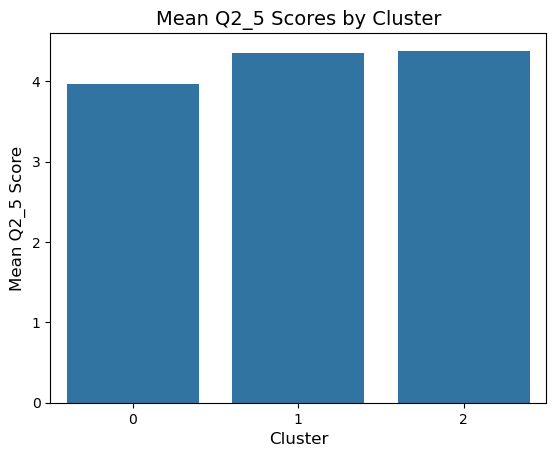

In [17]:
# Q2_5 Summary

subset_q2_5 = data.groupby('cluster')['Q2_5'].mean().round(2).reset_index()

# Visualize
sns.barplot(x='cluster', y='Q2_5', data=subset_q2_5)
plt.title('Mean Q2_5 Scores by Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Mean Q2_5 Score', fontsize=12)
plt.show()




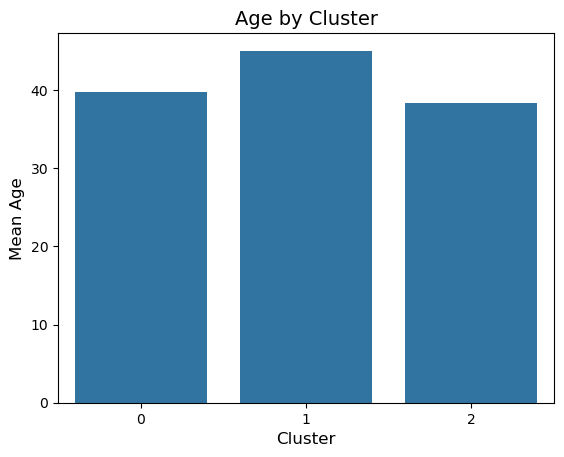

In [18]:
# AGE Summary

subset_age = data.groupby('cluster')['AGE'].mean().round(2).reset_index()

# Visualize
sns.barplot(x='cluster', y='AGE', data=subset_age)
plt.title('Age by Cluster', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Mean Age', fontsize=12)
plt.show()

#### Q3 Analysis

In [26]:
# Create dataframe summarizing means for each cluster

df_q3 = data.groupby('cluster')[all_psychographic_columns].mean().round(2).reset_index()
df_q3 = df_q3.melt(id_vars = 'cluster', var_name = 'question', value_name = 'mean_score') # Unpivot columns
df_q3['mean_score'] = df_q3['mean_score'].round(2) # Round mean
df_q3 = df_q3.pivot(index = 'question', columns = 'cluster', values = 'mean_score').reset_index() # Pivot cluster

df_q3

cluster,question,0,1,2
0,Q1_1,2.38,2.52,2.81
1,Q1_2,2.81,3.38,2.65
2,Q2_1,3.90,3.47,4.41
3,Q2_2,3.84,4.10,4.35
4,QS6_1,0.02,0.00,0.00
5,QS6_10,0.44,0.60,0.56
6,QS6_11,0.33,0.22,0.51
7,QS6_2,0.32,0.49,0.54
8,QS6_3,0.43,0.35,0.77
9,QS6_4,0.15,0.81,0.54


In [31]:
# Create subset with sport

subset_sport = df_q3[df_q3['question'].isin(['hqCycle', 'hqRun', 'hqTri'])] # Filter to sports
subset_sport = subset_sport.melt(id_vars = 'question', var_name = 'cluster', value_name = 'mean_score')
subset_sport

,question,cluster,mean_score
0,hqCycle,0,1.14
1,hqRun,0,1.37
2,hqTri,0,1.54
3,hqCycle,1,1.00
4,hqRun,1,1.64
5,hqTri,1,1.79
6,hqCycle,2,1.06
7,hqRun,2,1.15
8,hqTri,2,1.18


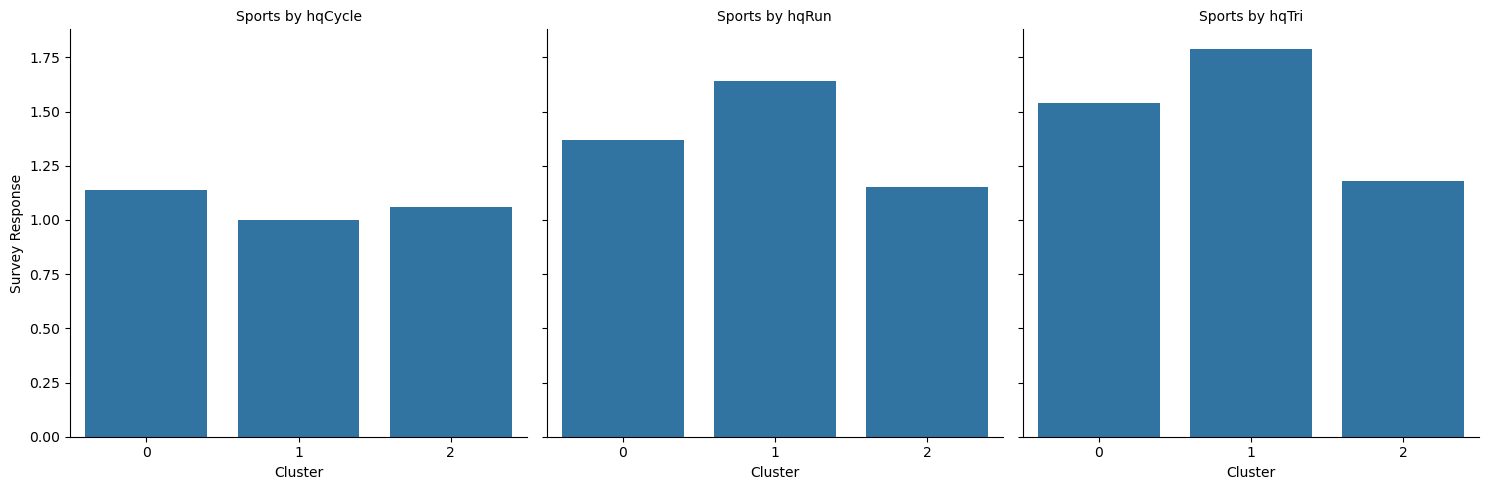

In [34]:
# Create the facet grid
g = sns.catplot(
    x='cluster', 
    y='mean_score', 
    col='question',  # Facet by the 'question' column
    data=subset_sport, 
    kind='bar'
)

g.set_titles("Sports by {col_name}")  # Title template for facets
g.set_axis_labels("Cluster", "Survey Response")  # Set axis labels

plt.show()